# Implementacja drzewa czwórkowego (quadtree)

In [5]:
from visualizer.main import Visualizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from quadtree import Point, Boundary, Quadtree, QuadtreeVisualizer

np.random.seed(420)

Funkcja do interaktywnego rysowania punktów

In [6]:
all_drawn_points = []

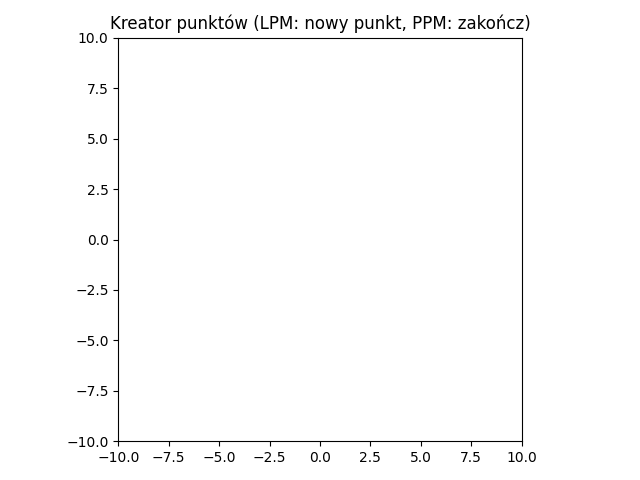

In [7]:
%matplotlib widget
fig, ax = plt.subplots()

current_points = []

def onclick(event):
    global current_points

    if event.inaxes != ax:
        return

    # lewy przycisk myszy - dodaj punkt
    if event.button == 1:
        x, y = event.xdata, event.ydata
        current_points.append(Point(x, y))
        ax.plot(x, y, 'bo')
        fig.canvas.draw_idle()

    # prawy przycisk myszy - zakończ rysowanie
    elif event.button == 3:
        fig.canvas.mpl_disconnect(cid)
        plt.pause(0.5)
        plt.close(fig)

        all_drawn_points.append(current_points)

ax.set_title("Kreator punktów (LPM: nowy punkt, PPM: zakończ)")
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect('equal')
plt.tight_layout()

cid = fig.canvas.mpl_connect('button_press_event', onclick)
plt.show()

Funkcje pomocnicze do zapisu i odczytu punktów z pliku

In [8]:
def save_points(all_points):
    df = pd.DataFrame(columns=["Count of points", "Points"])
    for x ,points in enumerate(all_points):
        df.loc[x] = {
            "Count of points": len(points),
            "Points": points
        }
    df.to_csv("results/points.csv", index=False)

def read_points(filename):
    try:
        df = pd.read_csv(filename)
    except FileNotFoundError:
        return []

    all_points = []
    for index, row in df.iterrows():
        all_points.append(eval(row["Points"]))
    return all_points

In [9]:
if len(all_drawn_points) > 0:
    save_points(all_drawn_points)
else:
    all_drawn_points = read_points("results/points.csv")

Funkcje generujące losowe punkty w zadanych granicach

In [10]:
def visualize_generators(n: int, func) -> Visualizer:
    boundary = Boundary.from_values(0, 50, 0, 50)
    random_points = func(boundary, n)
    vis = Visualizer()
    vis.add_point([(p.x, p.y) for p in random_points], color='blue')
    boundary.visualize(vis)
    return vis

Funkcja generująca losowe punkty w zadanych granicach

In [11]:
def generate_random_points(boundary: Boundary, n: int) -> list[Point]:
    points = []
    for _ in range(n):
        x = np.random.uniform(boundary.left_down.x, boundary.right_up.x)
        y = np.random.uniform(boundary.left_down.y, boundary.right_up.y)
        points.append(Point(x, y))
    return points

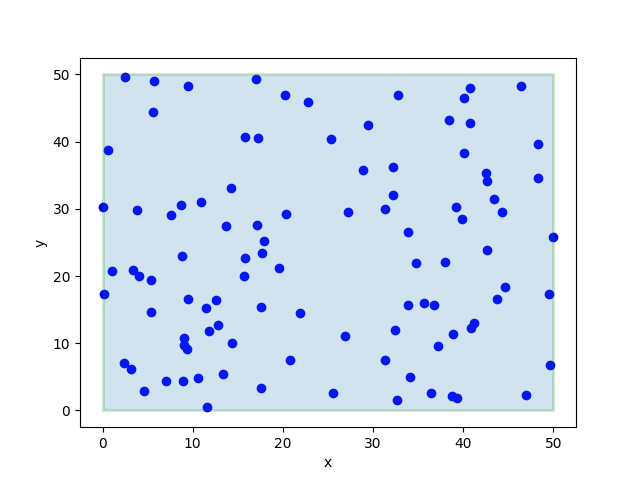

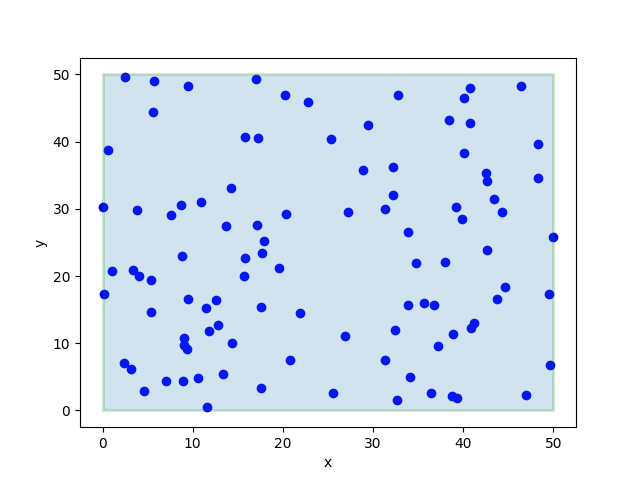

In [12]:
visualize_generators(100, generate_random_points).show()

Funkcja generująca punkty na przekątnej

In [13]:
def generate_collinear_points(boundary: Boundary, n: int) -> list[Point]:
    x1, y1 = boundary.left_down.x, boundary.left_down.y
    x2, y2 = boundary.right_up.x, boundary.right_up.y

    t_values = np.random.uniform(0, 1, n)
    points = [Point(x1 + t * (x2 - x1), y1 + t * (y2 - y1)) for t in t_values]
    return points

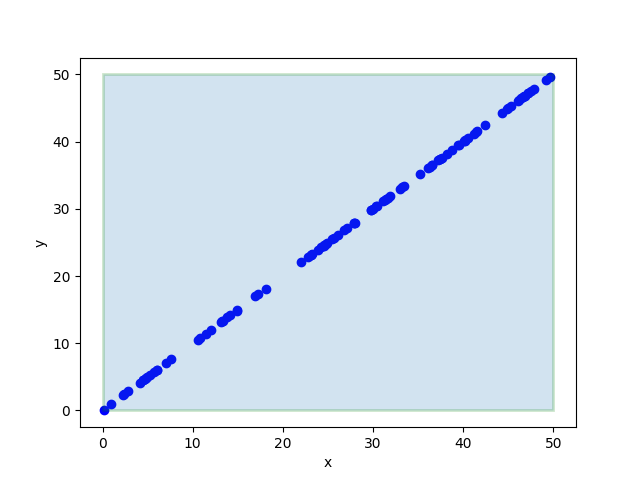

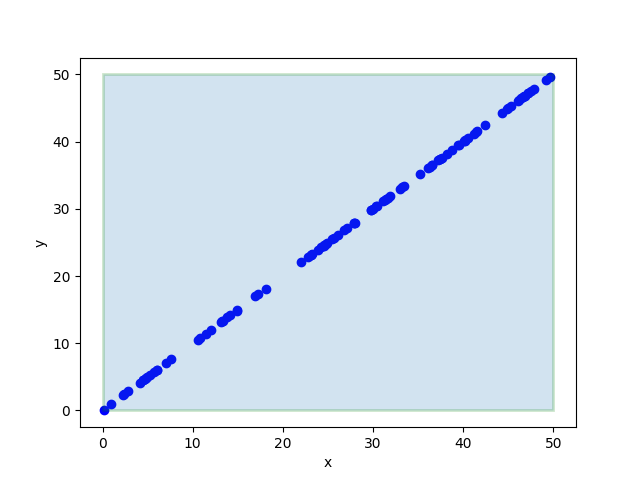

In [14]:
visualize_generators(100, generate_collinear_points).show()

Funkcja generująca punkty w trzech gęstych skupiskach

In [15]:
def generate_gesture_points(boundary: Boundary, n: int) -> list[Point]:
    width = boundary.right_up.x - boundary.left_down.x
    height = boundary.right_up.y - boundary.left_down.y

    # mniejszy = gęściej
    margin = 0.06 * min(width, height)

    centers = [
        Point(
            np.random.uniform(boundary.left_down.x, boundary.right_up.x),
            np.random.uniform(boundary.left_down.y, boundary.right_up.y),
        )
        for _ in range(3)
    ]

    base = n // 3
    counts = [base, base, n - 2 * base]

    points: list[Point] = []
    for c, k in zip(centers, counts):
        for _ in range(k):
            x = c.x + np.random.uniform(-margin, margin)
            y = c.y + np.random.uniform(-margin, margin)

            x = float(np.clip(x, boundary.left_down.x, boundary.right_up.x))
            y = float(np.clip(y, boundary.left_down.y, boundary.right_up.y))

            points.append(Point(x, y))

    return points

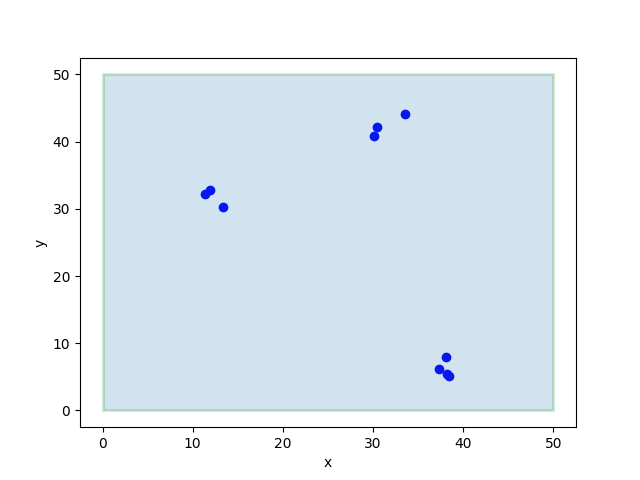

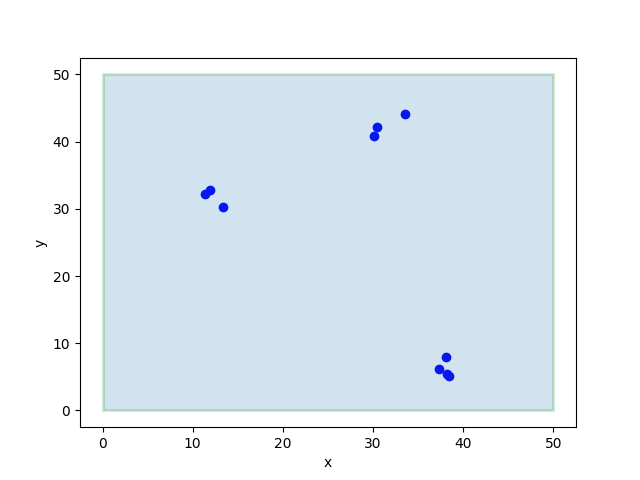

In [16]:
visualize_generators(10, generate_gesture_points).show()

Funkcja generująca punkty na krawędziach prostokąta

In [17]:
def generate_rectangle_points(boundary: Boundary, n: int) -> list[Point]:
    a = (boundary.left_down.x, boundary.left_down.y)
    b = (boundary.right_up.x, boundary.left_down.y)
    c = (boundary.right_up.x, boundary.right_up.y)
    d = (boundary.left_down.x, boundary.right_up.y)
    points = []
    for _ in range(n):
        side = np.random.randint(0, 4)
        t = np.random.uniform(0, 1)
        if side == 0:
            x = a[0] + t * (b[0] - a[0])
            y = a[1]
        elif side == 1:
            x = b[0]
            y = b[1] + t * (c[1] - b[1])
        elif side == 2:
            x = c[0] + t * (d[0] - c[0])
            y = c[1]
        else:
            x = d[0]
            y = d[1] + t * (a[1] - d[1])
        points.append(Point(x, y))

    return points

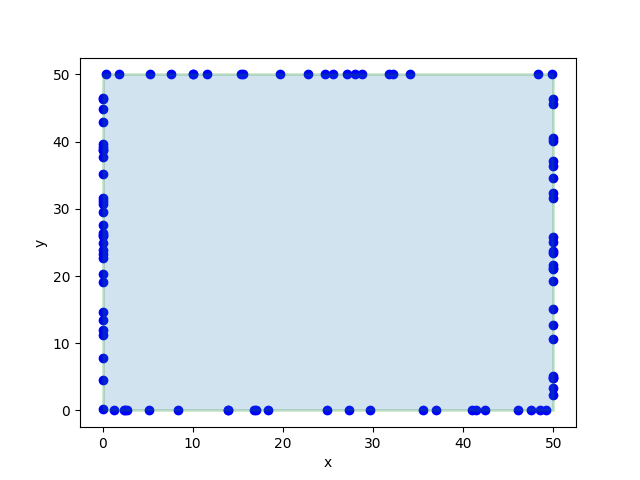

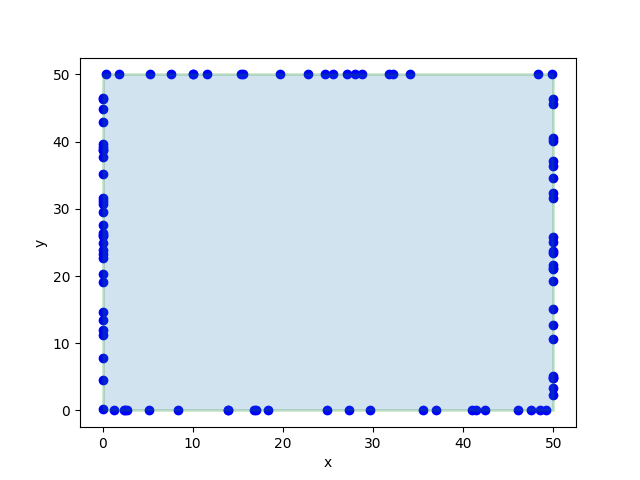

In [18]:
visualize_generators(100, generate_rectangle_points).show()

Funkcja generująca punkty na dolnej krawędzi prostokąta

In [19]:
def generate_one_edge_points(boundary: Boundary, n: int) -> list[Point]:
    a = (boundary.left_down.x, boundary.left_down.y)
    b = (boundary.right_up.x, boundary.left_down.y)
    points = []
    for _ in range(n):
        t = np.random.uniform(0, 1)
        x = a[0] + t * (b[0] - a[0])
        y = a[1]
        points.append(Point(x, y))
    return points

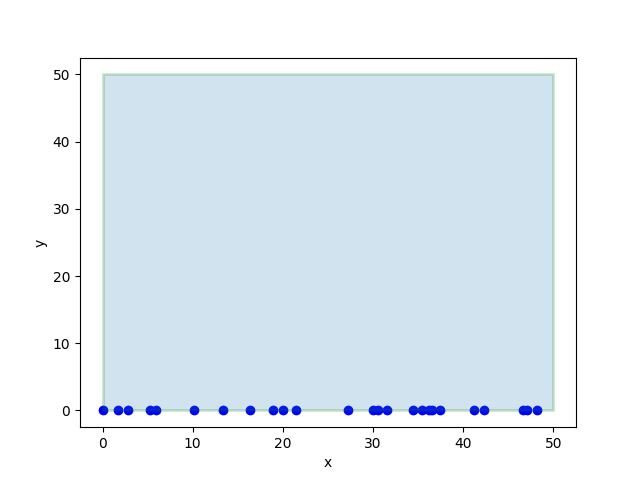

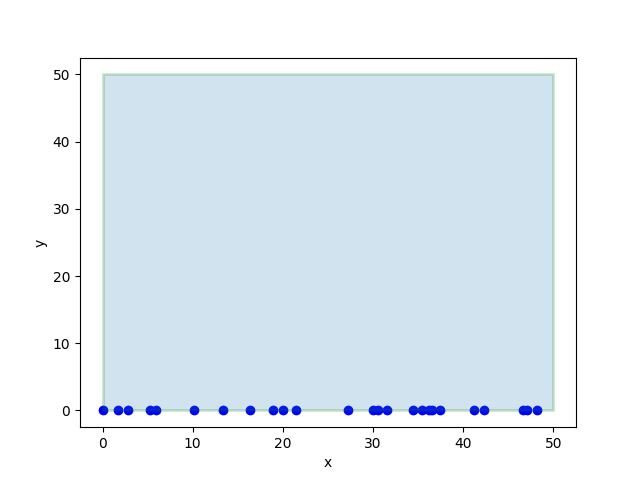

In [20]:
visualize_generators(25, generate_one_edge_points).show()

Przykładowa wizualizacja drzewa czwórkowego oraz operacji wyszukiwania

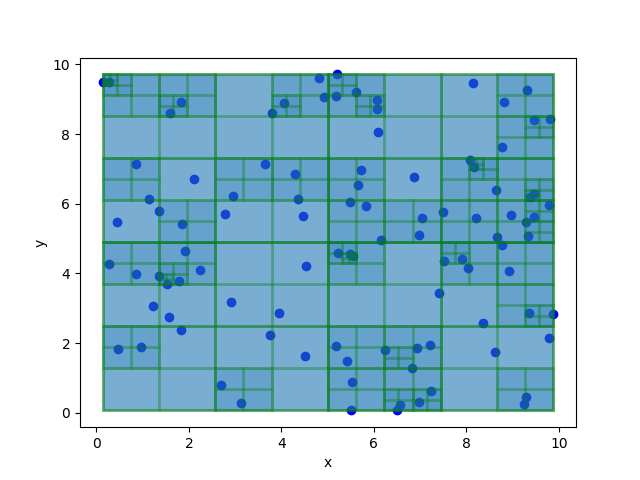

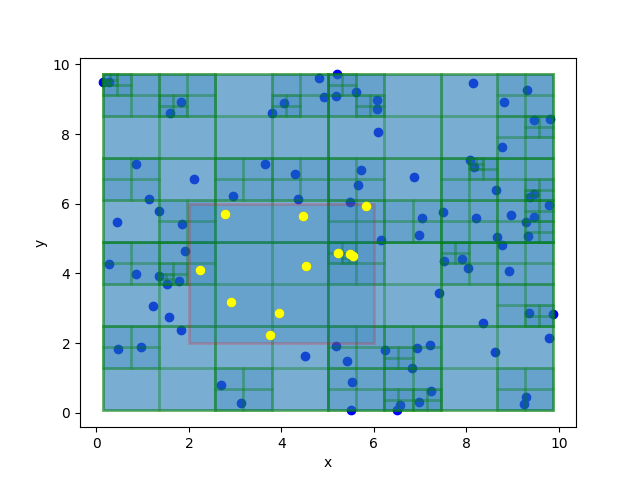

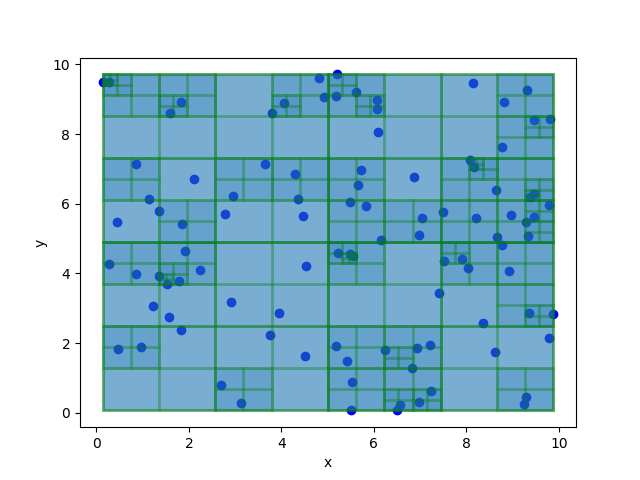

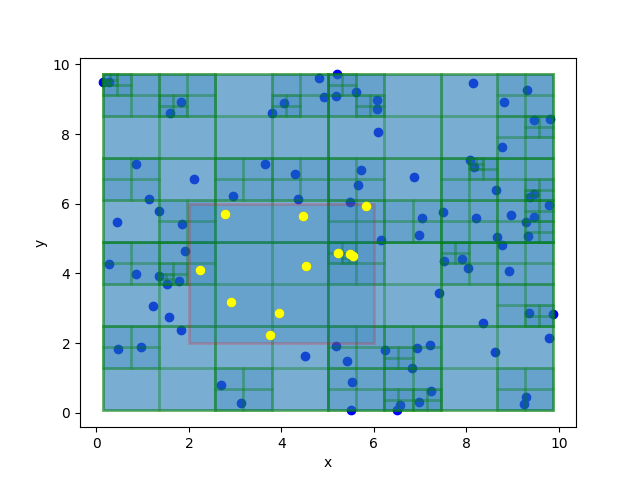

In [21]:
points = generate_random_points(Boundary.from_values(0, 10, 0, 10), 100)
tree = Quadtree.from_points(points)
search_boundary = Boundary.from_values(2, 6, 2, 6)
QuadtreeVisualizer(tree).show()
QuadtreeVisualizer(tree).visualize_search(search_boundary).show()

# QuadtreeVisualizer(tree).visualize_search_with_steps(search_boundary).show_gif(interval=600)

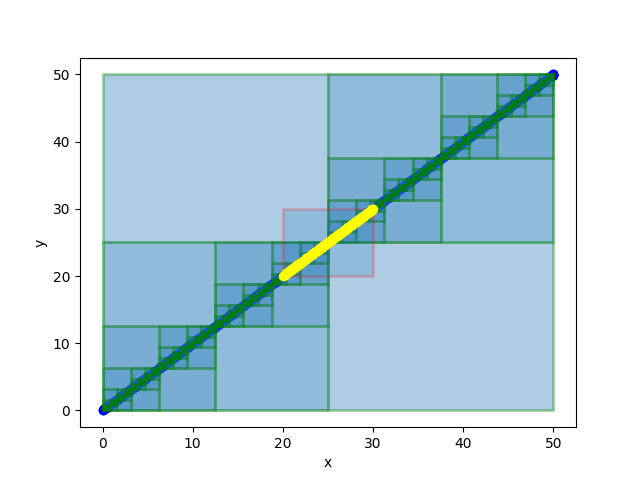

Points found: 199


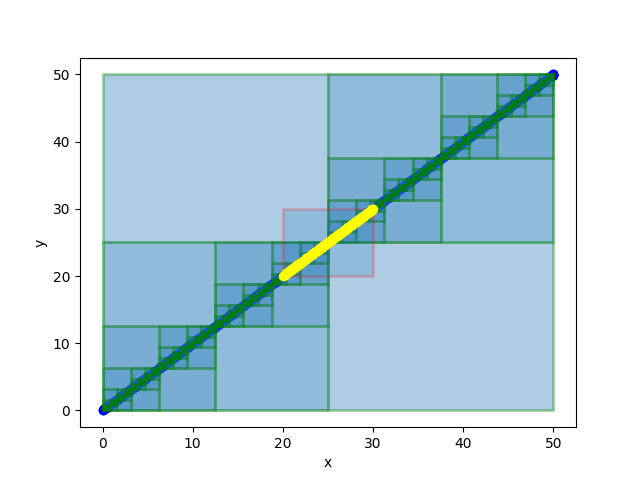

In [22]:
boundary = Boundary.from_values(0, 50, 0, 50)
points = generate_collinear_points(boundary, 1000)

tree = Quadtree(boundary, points)
vis_tree = QuadtreeVisualizer(tree)
search_boundary = Boundary.from_values(20, 30, 20, 30)
vis_tree.visualize_search(search_boundary).show()

print("Points found:", len(tree.search(search_boundary)))